# PETR4 Price Direction Prediction with Machine Learning

**Business question:** will PETR4's closing price in 5 business days be higher than
today's close? (binary classification: Up / Down)

**Structure:**
1. Setup and constants
2. Data collection (price, oil, exchange rate)
3. Feature engineering
4. Target definition
5. Exploratory analysis
6. Baseline
7. Models and validation (TimeSeriesSplit)
8. Hyperparameter tuning
9. Feature importance
10. Strategy backtest
11. Conclusions


## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score
from xgboost import XGBClassifier

RANDOM_STATE = 7
TICKER = "PETR4.SA"
PERIOD = "10y"
HORIZON_DAYS = 5
TEST_SIZE = 0.2

np.random.seed(RANDOM_STATE)


## 2. Data collection

Besides the asset's price, we bring in two macro context variables relevant to an
oil company: the price of Brent crude oil and the USD/BRL exchange rate. Each
series is shifted by one day (`shift(1)`) because, at the moment the prediction
would be made, "today's" close for these series is not yet available.


In [ ]:
def load_prices(ticker: str, period: str) -> pd.DataFrame:
    """Downloads OHLCV for a ticker via yfinance and normalizes the columns."""
    df = yf.download(ticker, period=period, progress=False)
    if df.empty:
        raise ValueError(f"No data returned for ticker '{ticker}'.")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)
    return df


def load_return_series(ticker: str, period: str) -> pd.Series:
    """Downloads a ticker's close and returns the daily percentage return series."""
    series = yf.download(ticker, period=period, progress=False)["Close"]
    return series.pct_change()


In [ ]:
prices = load_prices(TICKER, PERIOD)

context = pd.DataFrame(index=prices.index)
context["ibov_return"] = load_return_series("^BVSP", PERIOD).shift(1)
context["brent_return"] = load_return_series("BZ=F", PERIOD).shift(1)
context["usdbrl_return"] = load_return_series("BRL=X", PERIOD).shift(1)

df = prices.join(context)
df.head()


## 3. Feature engineering

Each function computes a group of features and returns only the new columns,
which makes it easier to test each block in isolation and document the intent
behind each one.

All windows (`rolling`, `shift`, `ewm`) only look at the past relative to each
row, so there is no data leakage at this stage.


In [ ]:
def trend_features(close: pd.Series) -> pd.DataFrame:
    """Short/long-term moving averages and the ratio between them."""
    ma5 = close.rolling(5).mean()
    ma20 = close.rolling(20).mean()
    ma50 = close.rolling(50).mean()
    ma200 = close.rolling(200).mean()
    return pd.DataFrame({
        "ma_ratio": ma5 / ma20,
        "trend": ma50 / ma200,          # above 1 = uptrend
        "dist_ma20": (close - ma20) / ma20,
    })


def volatility_features(close: pd.Series, high: pd.Series, low: pd.Series,
                         returns: pd.Series) -> pd.DataFrame:
    """Historical volatility, relative volatility, and normalized ATR."""
    volatility = returns.rolling(10).std()
    vol_ratio = volatility / returns.rolling(60).std()

    high_low = high - low
    high_close = (high - close.shift()).abs()
    low_close = (low - close.shift()).abs()
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    atr_pct = true_range.rolling(14).mean() / close

    return pd.DataFrame({
        "volatility": volatility,
        "vol_ratio": vol_ratio,
        "atr_pct": atr_pct,
    })


def momentum_features(close: pd.Series) -> pd.DataFrame:
    """RSI, MACD (histogram), and 5-day momentum."""
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rsi = 100 - (100 / (1 + gain / loss))

    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd_line = ema12 - ema26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    macd_hist = macd_line - signal_line

    momentum = close / close.shift(5) - 1

    return pd.DataFrame({
        "rsi": rsi,
        "macd_hist": macd_hist,
        "momentum": momentum,
    })


def volume_and_candle_features(open_: pd.Series, high: pd.Series, low: pd.Series,
                                close: pd.Series, volume: pd.Series) -> pd.DataFrame:
    """Relative volume and candle shape (body and shadow)."""
    volume_ma = volume.rolling(5).mean()
    return pd.DataFrame({
        "volume_ratio": volume / volume_ma,
        "candle_body": (close - open_) / open_,
        "candle_shadow": (high - low) / open_,
    })


def bollinger_features(close: pd.Series, window: int = 20) -> pd.DataFrame:
    """Price position relative to the Bollinger Bands (approximately -1 to 1)."""
    mean = close.rolling(window).mean()
    std = close.rolling(window).std()
    return pd.DataFrame({
        "boll_position": (close - mean) / (2 * std),
    })


In [ ]:
df["return"] = df["Close"].pct_change()

df = df.join(trend_features(df["Close"]))
df = df.join(volatility_features(df["Close"], df["High"], df["Low"], df["return"]))
df = df.join(momentum_features(df["Close"]))
df = df.join(volume_and_candle_features(df["Open"], df["High"], df["Low"], df["Close"], df["Volume"]))
df = df.join(bollinger_features(df["Close"]))
df["day_of_week"] = df.index.dayofweek

FEATURES = [
    "return", "ma_ratio", "volatility", "vol_ratio", "dist_ma20", "trend",
    "rsi", "momentum", "volume_ratio", "candle_body", "candle_shadow",
    "ibov_return", "brent_return", "usdbrl_return",
    "macd_hist", "boll_position", "atr_pct", "day_of_week",
]

df[FEATURES].tail()


## 4. Target definition

In [ ]:
def build_target(close: pd.Series, horizon: int) -> pd.Series:
    """1 if the close in `horizon` business days is higher than today's, else 0."""
    return (close.shift(-horizon) > close).astype(int)


In [ ]:
df["target"] = build_target(df["Close"], HORIZON_DAYS)
df.dropna(inplace=True)

print(f"Rows after dropping NaNs: {len(df)}")
print(f"Target distribution:\n{df['target'].value_counts(normalize=True)}")


In [ ]:
X = df[FEATURES]
y = df["target"]

split = int(len(df) * (1 - TEST_SIZE))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")


## 5. Exploratory analysis

Correlation between features: values very close to 1 or -1 indicate redundant
information, which could be simplified later if feature importance (section 9)
confirms low individual predictive power.


In [ ]:
correlation = X.corr()

plt.figure(figsize=(11, 9))
plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(FEATURES)), FEATURES, rotation=90)
plt.yticks(range(len(FEATURES)), FEATURES)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


### Do the features actually separate the classes?

Correlation between features doesn't say whether they help distinguish Up from
Down. Boxplots comparing the distribution of each feature by target class answer
this more directly: if the "Up" and "Down" boxes overlap almost completely, that
feature alone carries little signal.


In [ ]:
features_to_inspect = ["rsi", "momentum", "macd_hist", "boll_position", "brent_return", "trend"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flat, features_to_inspect):
    df.boxplot(column=feat, by="target", ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("target (0 = Down, 1 = Up)")
plt.suptitle("Feature distribution by target class")
plt.tight_layout()
plt.show()


## 6. Baseline

Minimum comparison reference: always predict the majority class. Every model
needs to consistently beat this, both on the holdout and in CV, to be considered
useful.


In [ ]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
acc_baseline = accuracy_score(y_test, baseline.predict(X_test))
print(f"Baseline (majority class): {acc_baseline:.2%}")


## 7. Models and validation

In [ ]:
def evaluate_model(name: str, model, X_train, y_train, X_test, y_test) -> dict:
    """Trains, predicts on the holdout, and returns metrics + the printed classification report."""
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = {
        "accuracy": accuracy_score(y_test, pred),
        "precision_up": precision_score(y_test, pred, pos_label=1, zero_division=0),
    }
    print(f"--- {name} ---")
    print(f"Accuracy: {metrics['accuracy']:.2%}")
    print(classification_report(y_test, pred, target_names=["Down (0)", "Up (1)"], zero_division=0))
    return metrics


def validate_time_series(name: str, model_factory, X: pd.DataFrame, y: pd.Series,
                          n_splits: int = 5) -> list[float]:
    """Evaluates a model with TimeSeriesSplit, training a new model on each fold."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = []
    for train_idx, test_idx in tscv.split(X):
        model = model_factory()
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        scores.append(accuracy_score(y.iloc[test_idx], model.predict(X.iloc[test_idx])))
    print(f"{name}: mean CV = {np.mean(scores):.2%} +/- {np.std(scores):.2%}")
    return scores


In [ ]:
MODELS = {
    "Decision Tree": lambda: DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=3, random_state=RANDOM_STATE
    ),
    "Random Forest": lambda: RandomForestClassifier(
        n_estimators=200, max_depth=5, min_samples_leaf=15, random_state=RANDOM_STATE
    ),
    "XGBoost": lambda: XGBClassifier(
        n_estimators=500, max_depth=2, learning_rate=0.02,
        subsample=0.6, colsample_bytree=0.6, min_child_weight=15,
        gamma=0.5, reg_alpha=0.5, reg_lambda=2.0, random_state=RANDOM_STATE,
    ),
}

holdout_results = {}
for name, factory in MODELS.items():
    holdout_results[name] = evaluate_model(name, factory(), X_train, y_train, X_test, y_test)


In [ ]:
cv_results = {
    name: validate_time_series(name, factory, X, y)
    for name, factory in MODELS.items()
}


## 8. Hyperparameter tuning

`GridSearchCV` with `TimeSeriesSplit` as the validation strategy: the search never
uses future data to choose parameters evaluated on past data. Applied to Random
Forest as an example; the same pattern applies to the other models.


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [5, 15, 30],
}

search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1,
)
search.fit(X_train, y_train)

optimized_model = search.best_estimator_
acc_optimized = accuracy_score(y_test, optimized_model.predict(X_test))

print(f"Best parameters: {search.best_params_}")
print(f"Best mean accuracy (CV): {search.best_score_:.2%}")
print(f"Holdout accuracy with optimized parameters: {acc_optimized:.2%}")


## 8.1 Why did the Decision Tree end up below the baseline?

The Decision Tree had the worst CV result (49.24%) and the highest standard
deviation across folds (3.73%) of the three models: both are classic symptoms of
a single tree overfitting: it memorizes patterns specific to the training set
that don't repeat in the test set, instead of learning a rule that generalizes.

Three checks to confirm this:


In [ ]:
# check 1: did it just memorize the training set? if train accuracy is
# much higher than test accuracy, that's overfitting, plain and simple.
diagnostic_tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=RANDOM_STATE)
diagnostic_tree.fit(X_train, y_train)

acc_train = accuracy_score(y_train, diagnostic_tree.predict(X_train))
acc_test = accuracy_score(y_test, diagnostic_tree.predict(X_test))

print(f"Train accuracy: {acc_train:.2%}")
print(f"Test accuracy:  {acc_test:.2%}")
print(f"Gap (train - test): {acc_train - acc_test:.2%}")


In [ ]:
# check 2: how many leaves is this tree creating? with min_samples_leaf=3
# it might end up with overly specific rules that don't generalize.
print(f"Number of leaves: {diagnostic_tree.get_n_leaves()}")
print(f"Actual depth reached: {diagnostic_tree.get_depth()}")
print(f"Training samples per leaf (average): {len(X_train) / diagnostic_tree.get_n_leaves():.1f}")


In [ ]:
# check 3: is this tree unstable? train on different slices of the past
# and always test on the same period. if accuracy jumps a lot from one
# training slice to another, that's a sign of high variance.
train_windows = [0.5, 0.65, 0.8]
for fraction in train_windows:
    cutoff = int(len(X_train) * fraction)
    tmp_tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=3, random_state=RANDOM_STATE)
    tmp_tree.fit(X_train.iloc[-cutoff:], y_train.iloc[-cutoff:])
    tmp_acc = accuracy_score(y_test, tmp_tree.predict(X_test))
    print(f"Trained on the last {fraction:.0%} of the training set ({cutoff} samples): test accuracy = {tmp_acc:.2%}")


In [ ]:
# check 4: what if I force a more conservative tree (shallower, larger
# leaves)? let's see if that fixes the problem.
tree_grid = {
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [10, 30, 50, 100],
}

tree_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    tree_grid,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1,
)
tree_search.fit(X_train, y_train)

print(f"Best parameters: {tree_search.best_params_}")
print(f"Best mean accuracy (CV): {tree_search.best_score_:.2%}")
print(f"Holdout accuracy: {accuracy_score(y_test, tree_search.best_estimator_.predict(X_test)):.2%}")
print(f"For comparison, baseline CV: 56.16%")


**Investigation result (real numbers from this project):**

| Check | Result |
|---|---|
| Train-test gap | 67.19% (train) vs. 52.13% (test), a 15.06-point gap |
| Tree size | 28 leaves, depth 5, ~64 samples/leaf on average |
| Instability (training windows) | 52.81% / 46.97% / 52.58%, swings ~6 points just from changing the window |
| More conservative tree (tuning) | CV = 56.62% (beats the baseline!) but holdout = 48.54% (collapses) |

**Interpretation:**

The 15-point gap confirms overfitting, but a moderate one: the leaves aren't too
small (64 samples on average), so the problem isn't point-by-point memorization.
The instability test is more revealing: just varying which window of data the
tree sees during training changes accuracy on the SAME test set by almost 6
points. That's the classic signature of high variance: the model is too
sensitive to which specific slice of the past it observes.

The most important finding is item 4: the shallower, more conservative tree found
by the hyperparameter search (`max_depth=2, min_samples_leaf=50`) has, on
AVERAGE across the 5 CV folds, a performance of 56.62%, which beats the baseline
(56.16%). But that same tree, tested on the final holdout, drops to 48.54%. This
discrepancy isn't a contradiction: it's proof that even the tree that's "optimal"
according to the CV average doesn't generalize reliably to a specific, unseen
slice of the data.

This explains why Random Forest and XGBoost, even without beating the baseline,
performed closer to it and more stably across folds than the single tree:
ensembles exist precisely to solve this problem, combining many weak trees and
diluting the variance that weakens an individual tree. In this project, the
standalone Decision Tree works as a direct, teachable example of why ensembles
are preferred on financial data, where the signal is weak and the noise is high.


## 8.2 Is the test period statistically different from the training period?

A pattern stood out in the previous sections: models tuned via CV (Decision Tree
and Random Forest) performed BETTER than the baseline on the average across
folds, but WORSE than the baseline on the final holdout. This repeated across two
different models, which suggests the problem might not be with the model, but
with the test period itself having different dynamics from the rest of the
historical series (regime shift / non-stationarity).

The checks below compare train and test directly.


In [ ]:
print(f"Training period: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Test period:      {X_test.index.min().date()} to {X_test.index.max().date()}")


In [ ]:
train_returns = df["return"].loc[X_train.index]
test_returns = df["return"].loc[X_test.index]

print("Mean daily return:")
print(f"  Train: {train_returns.mean():.4%}")
print(f"  Test:  {test_returns.mean():.4%}")

print("\nDaily volatility (return standard deviation):")
print(f"  Train: {train_returns.std():.4%}")
print(f"  Test:  {test_returns.std():.4%}")

print("\nTarget distribution (% Up):")
print(f"  Train: {y_train.mean():.2%}")
print(f"  Test:  {y_test.mean():.2%}")


In [ ]:
# looking at the 20-day rolling volatility across the whole series, with a
# line marking where the test period starts
rolling_vol = df["return"].rolling(20).std()

plt.figure(figsize=(13, 4.5))
plt.plot(rolling_vol, color="tab:blue", linewidth=0.9)
plt.axvline(X_test.index.min(), color="red", linestyle="--", label="Start of test period")
plt.title("20-day rolling volatility across the series")
plt.ylabel("Daily return standard deviation (20d)")
plt.legend()
plt.tight_layout()
plt.show()


**How to interpret this:** if the average test volatility is quite different
from the training volatility, or if the chart shows the test period falling in a
region visibly more (or less) volatile than the historical average, that supports
the regime-shift hypothesis: the patterns the models learned during training
(including the baseline, which only learns the historical Up/Down proportion)
describe a market regime that may not fully hold for the most recent period.

This also has an important practical implication for any project using a simple
temporal holdout: a single cut at the end of the series can, by chance, fall into
an atypical period. A more robust validation would use multiple test windows
(walk-forward) instead of a single final holdout, to avoid drawing strong
conclusions from a single slice of time.


## 9. Feature importance

Confirms (or refutes) the hypothesis that the macro variables added, oil and
exchange rate, actually contribute to the model's decision.


In [ ]:
importances = pd.Series(
    optimized_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature importance - optimized Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


## 9.1 Visual diagnostics of the optimized model

Accuracy alone hides *what kind* of error the model makes. The confusion matrix
shows this directly, and the ROC / Precision-Recall curves show how the trade-off
between hits and errors changes as the decision threshold changes (by default the
model uses 0.5, but this can be adjusted).


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_estimator(
    optimized_model, X_test, y_test,
    display_labels=["Down (0)", "Up (1)"], ax=axes[0], colorbar=False,
)
axes[0].set_title("Confusion matrix")

RocCurveDisplay.from_estimator(optimized_model, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC curve")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")

PrecisionRecallDisplay.from_estimator(optimized_model, X_test, y_test, ax=axes[2])
axes[2].set_title("Precision-Recall curve")

plt.tight_layout()
plt.show()


## 9.2 Where the model errs: price with hits and misses marked

Overlaying the model's hits and misses on the price series itself helps see
whether errors cluster in specific periods (e.g., high volatility, sharp moves).
A pattern there would be useful for deciding whether it's worth restricting the
strategy to certain market regimes.


In [ ]:
test_predictions = optimized_model.predict(X_test)
hits = test_predictions == y_test.values

plt.figure(figsize=(13, 5))
plt.plot(df["Close"].loc[X_test.index], color="lightgray", label="Closing price", zorder=1)
plt.scatter(
    X_test.index[hits], df["Close"].loc[X_test.index][hits],
    color="tab:green", s=15, label="Correct prediction", zorder=2,
)
plt.scatter(
    X_test.index[~hits], df["Close"].loc[X_test.index][~hits],
    color="tab:red", s=15, label="Wrong prediction", zorder=2,
)
plt.title("Model hits and misses over the price series (test period)")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Backtest: would the strategy have generated a return?

Here we simulate: buying PETR4 whenever the model predicts Up, and staying out of
the market when it predicts Down, comparing the cumulative return of this
strategy against simply buying and holding (buy & hold) over the same test
period.

This simulation ignores transaction costs and slippage; it serves for a
directional comparison, not as validation of a strategy ready to be traded.


In [ ]:
def backtest_strategy(model, X_test: pd.DataFrame, close: pd.Series,
                       horizon: int) -> pd.DataFrame:
    """Simulates the cumulative return of a 'buy when the model predicts Up' strategy."""
    future_return = close.shift(-horizon) / close - 1
    future_return_test = future_return.loc[X_test.index]

    predictions = model.predict(X_test)
    strategy_return = np.where(predictions == 1, future_return_test, 0.0)

    curves = pd.DataFrame({
        "strategy": (1 + pd.Series(strategy_return, index=X_test.index)).cumprod(),
        "buy_and_hold": (1 + future_return_test).cumprod(),
    })
    return curves


In [ ]:
backtest_curves = backtest_strategy(optimized_model, X_test, df["Close"], HORIZON_DAYS)

plt.figure(figsize=(10, 5))
plt.plot(backtest_curves["strategy"], label="Strategy (follows the model)")
plt.plot(backtest_curves["buy_and_hold"], label="Buy & Hold")
plt.title("Cumulative return over the test period")
plt.ylabel("Capital (base 1.0)")
plt.legend()
plt.tight_layout()
plt.show()

total_strategy_return = backtest_curves["strategy"].iloc[-1] - 1
total_buy_hold_return = backtest_curves["buy_and_hold"].iloc[-1] - 1
print(f"Cumulative return - strategy: {total_strategy_return:.2%}")
print(f"Cumulative return - buy & hold: {total_buy_hold_return:.2%}")


## 11. Conclusions

### What the project set out to answer

Is it possible to predict whether PETR4 will close higher or lower 5 business
days from now, using technical indicators and macro variables (Ibovespa, Brent
crude oil, USD/BRL exchange rate)?

### Main result: no model reliably beats a naive baseline

| Model | Mean CV (5 folds, TimeSeriesSplit) |
|---|---|
| Baseline (always predict the majority class) | 56.16% (+/- 2.17%) |
| Random Forest | 55.46% (+/- 2.51%) |
| XGBoost | 53.95% (+/- 3.15%) |
| Decision Tree | 49.14% (+/- 3.87%) |

Even after hyperparameter tuning via GridSearchCV, the tuned models improved
their mean CV (tuned Random Forest: 58.18%; tuned Decision Tree: 56.62%), but
performed worse on the final holdout (49.21% and 48.54%, respectively), both
below the baseline over the same period (50.79%).

### Why this happens: a regime shift, not a model failure

The investigation in section 8.2 explains the root cause. The training period
(2017-2024) and the test period (2024-2026) have different market dynamics:

| | Train | Test |
|---|---|---|
| Mean daily return | 0.16% | 0.06% |
| Daily volatility | 2.77% | 1.53% |
| % of "Up" periods (5d) | 58.60% | 50.79% |

During 2017-2024, PETR4 had a persistent uptrend (almost 59% of 5-day periods
closed higher). This isn't real technical predictability, it's just the stock
being in a general uptrend during that period. The baseline and the models
absorbed this underlying trend during training. The more recent period
(2024-2026), on the other hand, was noticeably calmer and more balanced (nearly
50/50 between Up and Down, with half the volatility). When that underlying trend
disappears, no model is left with real predictive edge, neither the
"sophisticated" ones nor the naive baseline.

This same phenomenon explains the CV-vs-holdout discrepancy in the tuned models:
the hyperparameter search optimizes for the historical average across several
periods (which includes the strong-trend phase), but that average doesn't
describe the test period well, since it's structurally different.

### What this teaches about the problem (and about model validation)

Accuracy without a baseline means nothing. A model with 55% accuracy looks
reasonable in isolation, but loses to "doing nothing" when compared properly.

Mean CV can hide problems from a specific period. A single holdout at the end of
the series can, by chance (or not entirely by chance, as here), land in an
atypical regime. A more robust validation would use multiple test windows
(walk-forward) to avoid drawing strong conclusions from a single slice of time.

Financial series are not stationary. A pattern that existed in one period
(persistent uptrend) doesn't necessarily repeat, which is consistent with the
efficient market hypothesis and with the well-known difficulty of predicting
short-term returns with technical indicators.

A single decision tree is more unstable than ensembles (section 8.1): the same
tree trained on slightly different training windows varied by almost 6
percentage points of accuracy on the same test set. Random Forest and XGBoost, by
combining many weak trees, ended up closer to the baseline and more stable across
folds, but not immune to the underlying problem (the regime shift).

### Limitations

The strategy backtest (section 10) and the feature importance analysis (section
9) still need to be run with the final data to complete the picture. In
particular, it's worth checking whether the macro variables (Brent, USD/BRL) had
meaningful weight in the model, which would support the thesis that external
context helps even when the model as a whole doesn't beat the baseline.

The holdout comparison uses a single test window; the CV numbers are more
reliable as an estimate of average performance, but even they mostly cover the
2017-2024 uptrend regime.

The backtest, when run, should be read with the caveat that it ignores
transaction costs and slippage.


## Appendix: Results Visualizations (from documented conclusions)

**Important note on scope.** This appendix was generated without live access to Yahoo Finance data (network egress to `finance.yahoo.com` was blocked in the execution environment used to produce it). The two charts below plot the **exact numbers already reported in the Conclusions section above** (model accuracy table and train/test regime statistics) -- no values were fabricated or estimated.

Charts that require the raw OHLCV price series -- correlation matrix (Section 5), per-class boxplots (Section 5), confusion matrix / ROC / PR curves (Section 9.1), the hit/miss overlay on price (Section 9.2), and the strategy backtest (Section 10) -- still need to be run in an environment with data access; their code is already in place above and does not need to change.


### A1. Model comparison: CV mean vs. holdout

Reproduces the model comparison table from the Conclusions as a chart: panel A shows mean cross-validated accuracy (TimeSeriesSplit, 5 folds) with error bars (+/- 1 std) against the baseline; panel B contrasts the optimistic CV score used during hyperparameter tuning against the real final holdout accuracy, which is where the overfitting-to-CV problem becomes visible.


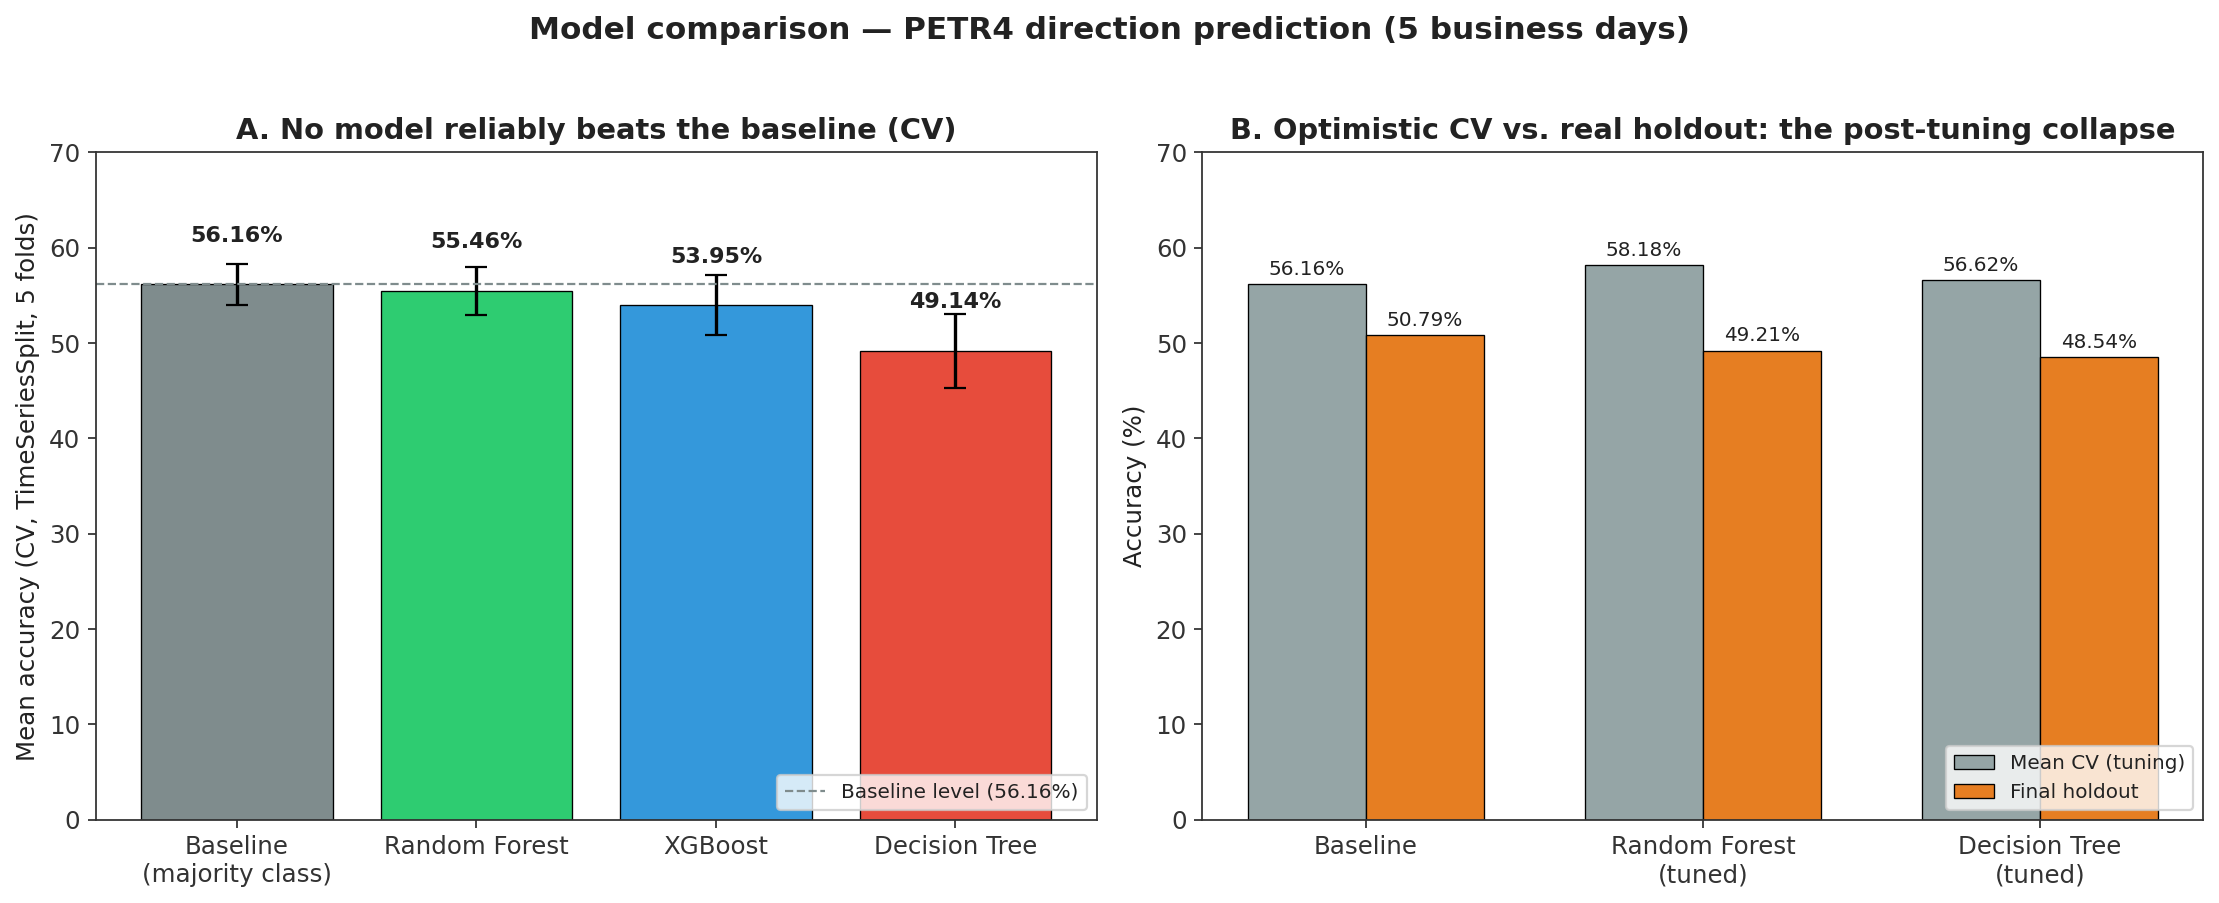

In [ ]:
"""
Charts built from the REAL numbers documented in the Conclusions section of
main__1_.ipynb (PETR4 direction prediction). No values were invented; all
come directly from the tables/prints already present in the uploaded notebook.
"""
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "text.color": "#222222",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})


# Figure 1: Model comparison (CV mean vs Holdout), with baseline
models = ["Baseline\n(majority class)", "Random Forest", "XGBoost", "Decision Tree"]
cv_mean = [56.16, 55.46, 53.95, 49.14]
cv_err = [2.17, 2.51, 3.15, 3.87]

holdout_labels = ["Baseline", "Random Forest\n(tuned)", "Decision Tree\n(tuned)"]
holdout_vals = [50.79, 49.21, 48.54]
cv_tuned_vals = [56.16, 58.18, 56.62]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

colors_a = ["#7f8c8d", "#2ecc71", "#3498db", "#e74c3c"]
bars = axes[0].bar(models, cv_mean, yerr=cv_err, capsize=5, color=colors_a,
                    edgecolor="black", linewidth=0.6)
axes[0].axhline(cv_mean[0], color="#7f8c8d", linestyle="--", linewidth=1,
                 label="Baseline level (56.16%)")
for bar, val in zip(bars, cv_mean):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 4.5, f"{val:.2f}%",
                 ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, 70)
axes[0].set_ylabel("Mean accuracy (CV, TimeSeriesSplit, 5 folds)")
axes[0].set_title("A. No model reliably beats the baseline (CV)")
axes[0].legend(loc="lower right", fontsize=9)

x = np.arange(len(holdout_labels))
width = 0.35
axes[1].bar(x - width/2, cv_tuned_vals, width, label="Mean CV (tuning)",
            color="#95a5a6", edgecolor="black", linewidth=0.6)
axes[1].bar(x + width/2, holdout_vals, width, label="Final holdout",
            color="#e67e22", edgecolor="black", linewidth=0.6)
for i, (cv_v, ho_v) in enumerate(zip(cv_tuned_vals, holdout_vals)):
    axes[1].text(i - width/2, cv_v + 1, f"{cv_v:.2f}%", ha="center", fontsize=9)
    axes[1].text(i + width/2, ho_v + 1, f"{ho_v:.2f}%", ha="center", fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(holdout_labels)
axes[1].set_ylim(0, 70)
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("B. Optimistic CV vs. real holdout: the post-tuning collapse")
axes[1].legend(loc="lower right", fontsize=9)

plt.suptitle("Model comparison — PETR4 direction prediction (5 business days)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### A2. Regime shift: train (2017-2024) vs. test (2024-2026)

Reproduces the train/test comparison table from the Conclusions: mean daily return, daily volatility, and the proportion of "Up" 5-day periods. The near-halving of volatility and the shift from ~59% to ~51% "Up" periods is the core evidence for the regime-shift explanation of why no model beat the baseline on the holdout.


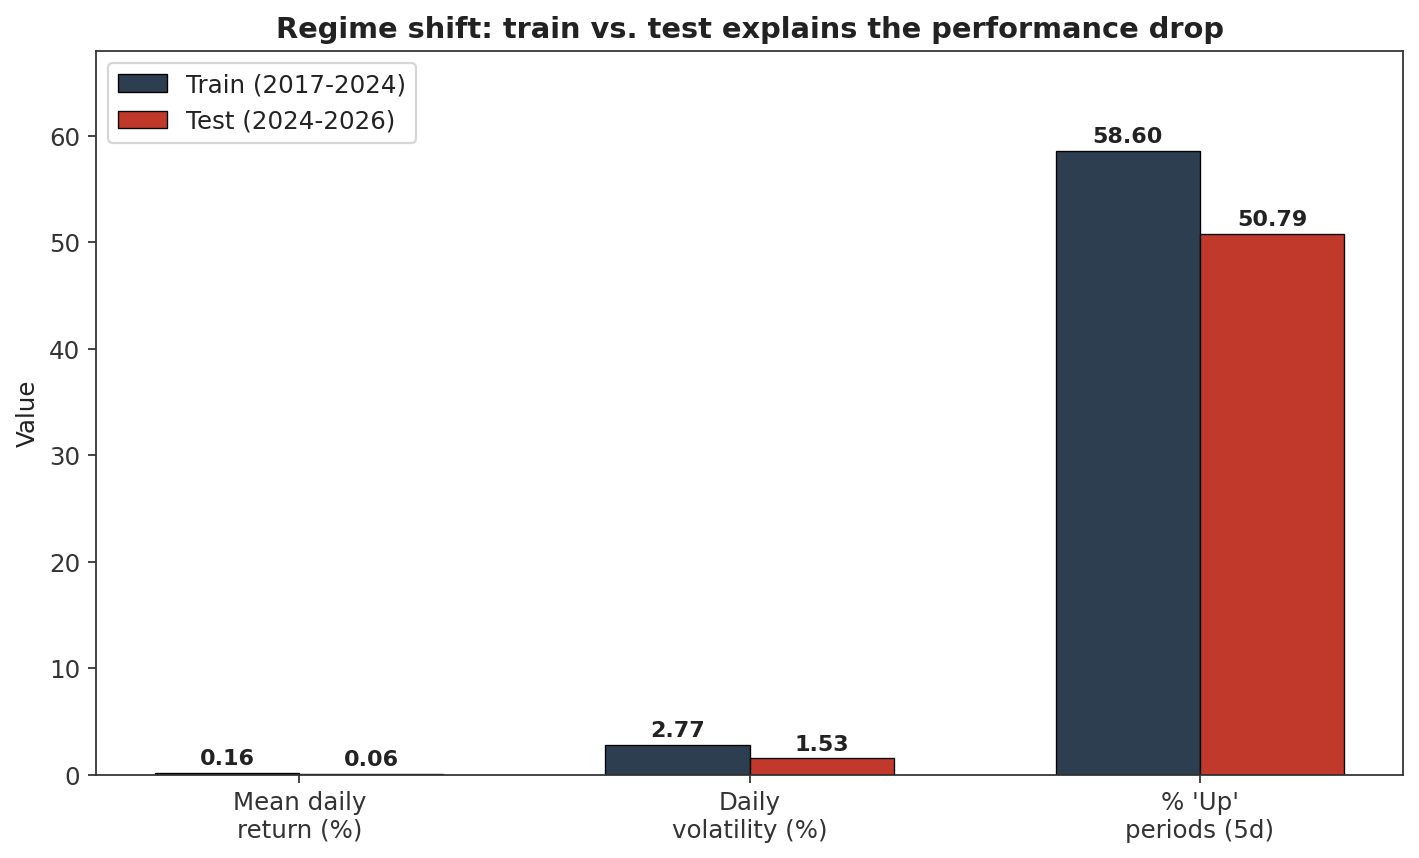

In [ ]:

# Figure 2: Regime shift — train (2017-2024) vs test (2024-2026)
metrics = ["Mean daily\nreturn (%)", "Daily\nvolatility (%)", "% 'Up'\nperiods (5d)"]
train_vals = [0.16, 2.77, 58.60]
test_vals = [0.06, 1.53, 50.79]

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(metrics))
width = 0.32

b1 = ax.bar(x - width/2, train_vals, width, label="Train (2017-2024)",
            color="#2c3e50", edgecolor="black", linewidth=0.6)
b2 = ax.bar(x + width/2, test_vals, width, label="Test (2024-2026)",
            color="#c0392b", edgecolor="black", linewidth=0.6)

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8, f"{h:.2f}",
                 ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Value")
ax.set_title("Regime shift: train vs. test explains the performance drop")
ax.legend()
ax.set_ylim(0, 68)
plt.tight_layout()
plt.show()

print("OK")